In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 57.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import zipfile
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [ ]:
# torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader , Dataset,random_split
from torchmetrics.classification import BinaryAccuracy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_file_path = '/content/drive/MyDrive/Shop DataSet.zip'
extract_directory = '/content'

os.makedirs(extract_directory, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_directory)

In [ ]:
shop_lifters_path="/content/Shop DataSet/shop lifters"
shop_nonlifters_path="/content/Shop DataSet/non shop lifters"

In [ ]:
shop_lifters = [os.path.join(shop_lifters_path,i) for i in os.listdir(shop_lifters_path)]
shop_nonlifters = [os.path.join(shop_nonlifters_path,i) for i in os.listdir(shop_nonlifters_path)]

In [ ]:
print(len(shop_lifters))
print(len(shop_nonlifters))

324
528


In [ ]:
def number_frames(video_path):
  cap = cv2.VideoCapture(video_path)
  frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
  cap.release()
  return frame_count

In [ ]:
def number_fps(video_path):
  cap = cv2.VideoCapture(video_path)
  fps = int(cap.get(cv2.CAP_PROP_FPS))
  cap.release()
  return fps

In [ ]:
def find_min_frames(video_list):
    min_frames = float('inf')

    for video_path in video_list:
        frames = number_frames(video_path)
        if frames < min_frames:
            min_frames = frames

    print(f"The least number of frames: {min_frames}")

# Combine both lists if you want to check all videos
all_videos = shop_lifters + shop_nonlifters

find_min_frames(all_videos)

The least number of frames: 75


In [ ]:
shop_lifters_frames = [
    number_frames(i)
    for i in shop_lifters
]

shop_nonlifters_frames = [
    number_frames(i)
    for i in shop_nonlifters
]
shop_lifters_fps = [
    number_fps(i)
    for i in shop_lifters
]

shop_nonlifters_fps = [
    number_fps(i)
    for i in shop_nonlifters
]

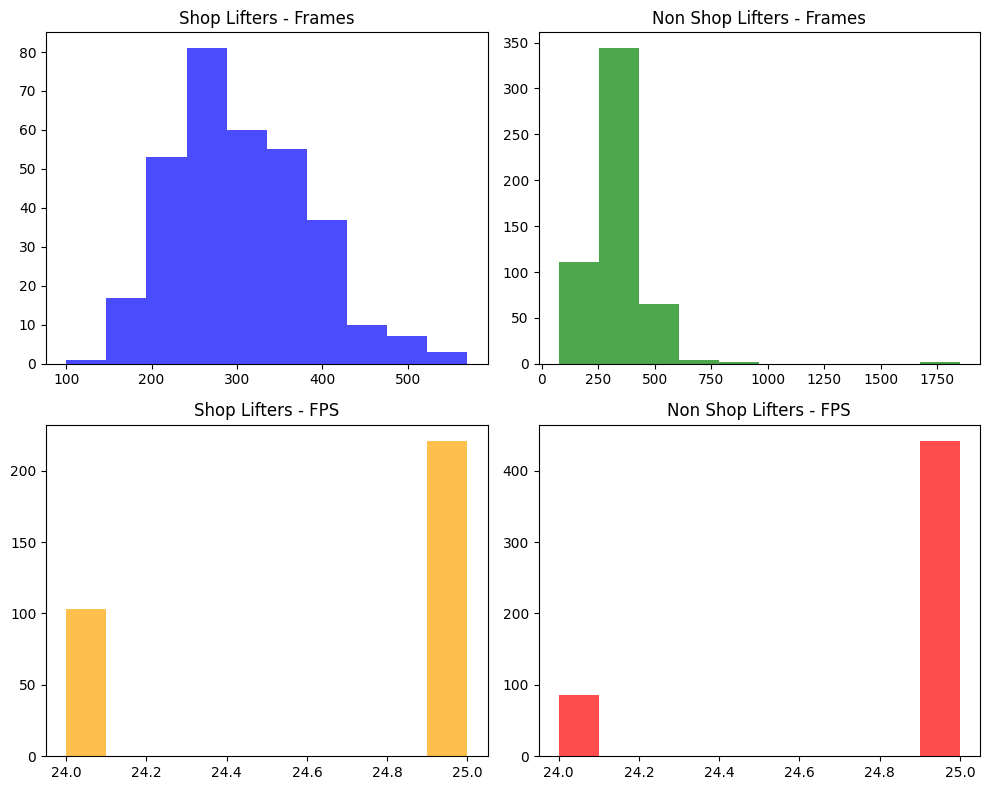

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(shop_lifters_frames, bins=10, color='blue', alpha=0.7)
axes[0, 0].set_title("Shop Lifters - Frames")

axes[0, 1].hist(shop_nonlifters_frames, bins=10, color='green', alpha=0.7)
axes[0, 1].set_title("Non Shop Lifters - Frames")

axes[1, 0].hist(shop_lifters_fps, bins=10, color='orange', alpha=0.7)
axes[1, 0].set_title("Shop Lifters - FPS")

axes[1, 1].hist(shop_nonlifters_fps, bins=10, color='red', alpha=0.7)
axes[1, 1].set_title("Non Shop Lifters - FPS")

plt.tight_layout()
plt.show()

In [ ]:
class Shop_Dataset(Dataset):
    def __init__(self, shop_lifters, shop_nonlifters, transform=None):
        self.shop_lifters = shop_lifters
        self.shop_nonlifters = shop_nonlifters
        self.transform = transform

    def __len__(self):
        return len(self.shop_lifters) + len(self.shop_nonlifters)

    def __getitem__(self, idx):

        if idx < len(self.shop_lifters):
            video_path = self.shop_lifters[idx]
            label = 1
        else:
            video_path = self.shop_nonlifters[idx - len(self.shop_lifters)]
            label = 0

        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        indices = np.linspace(0, total_frames - 1, 16, dtype=int)
        frames = []

        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Convert the NumPy array to a PIL Image before applying transforms
            frame = Image.fromarray(frame)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)

        cap.release()

        frames = torch.stack(frames)

        label = torch.tensor(label, dtype=torch.long)

        return frames, label

In [ ]:
dataset = Shop_Dataset(shop_lifters, shop_nonlifters, transform=tranform)

train_size = int(0.8 * len(dataset))
val_size=int(0.1 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset,val_dataset,test_dataset = random_split(dataset, [train_size,val_size,test_size])

In [ ]:
from torchvision import transforms
from torch.utils.data import random_split
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

# Define two separate transform pipelines
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])


train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.video import r2plus1d_18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = r2plus1d_18(pretrained=True)


num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.LayerNorm(512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, 2)
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the last layer
for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
num_epochs = 20

# ----- Training loop -----
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=True)

    for frames, labels in loop:
        frames, labels = frames.to(device), labels.to(device)
        frames = frames.permute(0, 2, 1, 3, 4)  # (B, C, T, H, W)

        outputs = model(frames)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # ----- VALIDATION -----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for frames, labels in val_loader:
            frames, labels = frames.to(device), labels.to(device)
            frames = frames.permute(0, 2, 1, 3, 4)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    print(f"\nEpoch [{epoch+1}/{num_epochs}] Summary:")
    print(f"  Train → Loss: {running_loss/len(train_loader):.4f} | Acc: {100*correct/total:.2f}%")
    print(f"  Val   → Loss: {val_loss/len(val_loader):.4f} | Acc: {100*val_correct/val_total:.2f}%\n")

Epoch [1/20]: 100%|██████████| 171/171 [09:16<00:00,  3.26s/it, acc=61.1, loss=0.989]



Epoch [1/20] Summary:
  Train → Loss: 0.6571 | Acc: 61.09%
  Val   → Loss: 0.6418 | Acc: 61.18%



Epoch [2/20]: 100%|██████████| 171/171 [09:21<00:00,  3.29s/it, acc=62.8, loss=0.682]



Epoch [2/20] Summary:
  Train → Loss: 0.6424 | Acc: 62.85%
  Val   → Loss: 0.6545 | Acc: 61.18%



Epoch [3/20]: 100%|██████████| 171/171 [09:17<00:00,  3.26s/it, acc=60.8, loss=0.368]


...


Epoch [18/20] Summary:
  Train → Loss: 0.4958 | Acc: 77.53%
  Val   → Loss: 0.3045 | Acc: 88.24%



Epoch [19/20]: 100%|██████████| 171/171 [09:27<00:00,  3.32s/it, acc=79.3, loss=0.831]



Epoch [19/20] Summary:
  Train → Loss: 0.4415 | Acc: 79.30%
  Val   → Loss: 0.2796 | Acc: 92.94%



Epoch [20/20]: 100%|██████████| 171/171 [09:22<00:00,  3.29s/it, acc=79, loss=0.08]



Epoch [20/20] Summary:
  Train → Loss: 0.4313 | Acc: 79.00%
  Val   → Loss: 0.2698 | Acc: 90.59%



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Evaluation ---
model.eval()
y_true, y_pred = [], []
val_loss = 0.0

with torch.no_grad():
    loop = tqdm(test_loader, desc="Evaluating", leave=False)
    for frames, labels in loop:
        frames, labels = frames.to(device), labels.to(device)

        frames = frames.permute(0, 2, 1, 3, 4)

        outputs = model(frames)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# --- Compute Metrics ---
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("📊 Evaluation Results:")
print(f"Loss:      {val_loss/len(val_loader):.4f}")
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")